# Fault_Tolerant_Sim — end-to-end demo

Compile a logical `{H, S, T, CNOT}` circuit into one `[[6,2,2]]` circuit (one
code patch per logical qubit; `H/S/CNOT` transversal; each `T` distilled in the
H6 `[[6,2,2]]` factory and gate-teleported), then simulate it under
circuit-level depolarising noise with **clifft** (real `T` gates) and score by
post-selection.

- **acceptance** = post-selection yield (`[[6,2,2]]` is `d=2` → detection only)
- **LER** = logical error rate on the round-trip `lc ; lc†` (deterministic output)
- **noiseless_error_floor** = residual coherent error of the T gadget at `p=0`
  (bare `[[6,2,2]]` has no exact transversal `T`; a `T` conjugated by `H`
  carries ~7%). `logical_error_rate_net` subtracts it.
- **unitary_check** = compiled noiseless output distribution vs a dense
  state-vector reference.

## Step 0 — validate the package

Run the `ftsim` test suite (compile / factory / gadget / pipeline / clifft
smoke). If anything fails, stop — the sweep below would only produce garbage.

In [59]:
import subprocess, sys
from pathlib import Path

ROOT = Path.cwd().parent
p = subprocess.run([sys.executable, '-m', 'pytest', str(ROOT / 'tests'), '-q', '--no-header'],
                   cwd=ROOT, capture_output=True, text=True)
print(p.stdout[-2000:])
if p.returncode != 0:
    print(p.stderr[-2000:])
    raise RuntimeError(f'ftsim tests failed (exit {p.returncode})')
print('OK — ftsim validated.')

.................................                                        [100%]

OK — ftsim validated.


In [60]:
import pandas as pd
from ftsim import LogicalCircuit, run_pipeline


## Configure the logical circuit

A `LogicalCircuit` is a list of `('H', q) | ('S', q) | ('T', q) | ('CNOT', c, t)`
(plus `S_DAG`, `T_DAG`, `X`). Keep the T-count small — clifft cost grows with
simultaneously-live magic, and acceptance falls ~2× per `T`.

In [ ]:
# A small T-using circuit. (Avoid a T immediately conjugated by H on the same
# qubit -- bare [[6,2,2]] transversal T is not exact there; it shows up as the
# noiseless_error_floor.)
lc = LogicalCircuit([
    ('T', 1)
])
lc

LogicalCircuit(n=2, t=1, [H(0,), CNOT(0, 1), T(1,)])

## The physical circuit submitted to clifft

`run_pipeline` scores LER on the round-trip `lc ; lc†`, so it compiles
`bench_lc = lc.gates + lc.inverse().gates` into **one `[[6,2,2]]` circuit**
(`compile_lc(...).text`). That clifft text — H6 encoders, SE rounds with
`DETECTOR`s, transversal `H/S/CNOT`, one T-teleport block per `T`, final `Z`
readout + `OBSERVABLE_INCLUDE` + consistency detectors — is what gets handed to
`clifft.compile` / `clifft.sample`:

- `reference()` submits it **verbatim** (noiseless) to fix the post-selection pattern.
- `run(p)` submits `add_noise(text, p, mode)` — the same circuit with
  `DEPOLARIZE1/2` + `X_ERROR/Z_ERROR` lines inserted after every gate / reset / measure.

In [62]:
from ftsim.processor import compile as compile_lc
from ftsim.sim.noise import add_noise

# exactly what run_pipeline builds internally
bench_lc = LogicalCircuit(list(lc.gates) + list(lc.inverse().gates))
comp = compile_lc(bench_lc, input_state='0' * lc.n_qubits, factory_se_rounds=1)

print(f'physical qubits : {comp.n_qubits}')
print(f'detectors       : {comp.n_detectors} '
      f'({len(comp.qec_detectors)} QEC + {len(comp.sbranch_detectors)} S-branch)')
print(f'observables     : {comp.n_observables}')
print(f'circuit lines   : {comp.text.count(chr(10))}')
print('=' * 70)
print(comp.text)                       # <-- noiseless circuit submitted by reference()

print('#' * 70, '\n# with p=0.001 depolarising noise (what run(p) submits):\n')
print(add_noise(comp.text, 0.001, 'full'))


physical qubits : 48
detectors       : 74 (60 QEC + 14 S-branch)
observables     : 2
circuit lines   : 261
R 0 1 2 3 4 5 12 13 14 15 16 17
H 0 1
H 2 4
CX 2 3
CX 4 5
CX 2 0
CX 3 1
CX 0 4
CX 1 5
CX 4 2
CX 5 3
H 0 1 2 3 4 5
H 12 13
H 14 16
CX 14 15
CX 16 17
CX 14 12
CX 15 13
CX 12 16
CX 13 17
CX 16 14
CX 17 15
H 12 13 14 15 16 17
R 6 7 8 9
H 6 7
CX 6 0 6 1 6 2 6 3
CX 7 2 7 3 7 4 7 5
CX 0 8 1 8 2 8 3 8
CX 2 9 3 9 4 9 5 9
H 6 7
M 6 7 8 9
R 18 19 20 21
H 18 19
CX 18 12 18 13 18 14 18 15
CX 19 14 19 15 19 16 19 17
CX 12 20 13 20 14 20 15 20
CX 14 21 15 21 16 21 17 21
H 18 19
M 18 19 20 21
DETECTOR rec[-8]
DETECTOR rec[-7]
DETECTOR rec[-6]
DETECTOR rec[-5]
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
H 0 1 2 3 4 5
R 6 7 8 9
H 6 7
CX 6 0 6 1 6 2 6 3
CX 7 2 7 3 7 4 7 5
CX 0 8 1 8 2 8 3 8
CX 2 9 3 9 4 9 5 9
H 6 7
M 6 7 8 9
R 18 19 20 21
H 18 19
CX 18 12 18 13 18 14 18 15
CX 19 14 19 15 19 16 19 17
CX 12 20 13 20 14 20 15 20
CX 14 21 15 21 16 21 17 21
H 18 19
M 18 19 20 21
D

## Sweep the physical error rate

In [63]:
import numpy as np, clifft
from ftsim.sim.noise import add_noise

def bare_ler(lc, p, shots, seed=0, mode='full'):
    """LER of the *unencoded* round-trip lc ; lc.inverse(): one physical qubit
    per logical qubit, physical T gates, no [[6,2,2]] code, no post-selection.
    Ideal output = all-zeros."""
    n = lc.n_qubits
    nl = chr(10)
    gates = list(lc.gates) + list(lc.inverse().gates)
    q_all = ' '.join(map(str, range(n)))
    lines = [f'R {q_all}']
    for g in gates:
        lines.append(f'CX {g[1]} {g[2]}' if g[0] == 'CNOT' else f'{g[0]} {g[1]}')
    lines.append(f'M {q_all}')
    lines += [f'OBSERVABLE_INCLUDE({q}) rec[{q - n}]' for q in range(n)]
    r = clifft.sample(clifft.compile(add_noise(nl.join(lines) + nl, p, mode)),
                      shots=shots, seed=seed)
    obs = np.asarray(r.observables, dtype=np.uint8)
    return float((obs != 0).any(axis=1).mean())

P_VALUES = [0.0, 0.001, 0.002, 0.003]
SHOTS = 100_000

rows = []
for p in P_VALUES:
    r = run_pipeline(lc, p=p, shots=SHOTS, check=(p == 0.0))
    rows.append({
        'p': p,
        'accept': r.post_selection_rate,
        'LER': r.logical_error_rate,
        'LER_net': r.logical_error_rate_net,
        'LER_bare': bare_ler(lc, p, SHOTS),
        'floor': r.noiseless_error_floor,
        'passed': r.passed_shots,
        'seconds': round(r.seconds, 1),
    })

df = pd.DataFrame(rows)
df

,p,accept,LER,LER_net,LER_bare,floor,passed,seconds
0,0.000,0.09809,0.179529,0.000000,0.00000,0.179932,9809,0.5
1,0.001,0.05811,0.183617,0.003685,0.00913,0.179932,5811,0.4
2,0.002,0.03368,0.195071,0.015139,0.01782,0.179932,3368,0.4
3,0.003,0.02032,0.211614,0.031682,0.02685,0.179932,2032,0.6


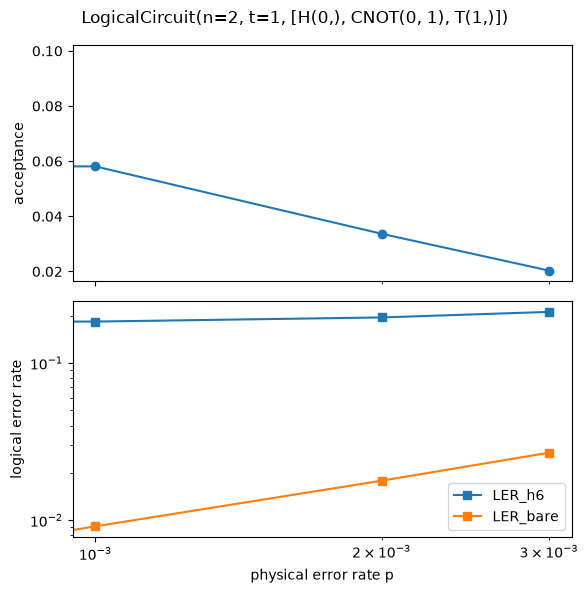

In [64]:
import matplotlib.pyplot as plt

fig, (ax_acc, ax_ler) = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
fig.suptitle(str(lc))

df.plot(x='p', y='accept', marker='o', ax=ax_acc, legend=False)
ax_acc.set_ylabel('acceptance')

df.plot(x='p', y=['LER', 'LER_bare'], marker='s', ax=ax_ler)
ax_ler.legend(['LER_h6', 'LER_bare'])
ax_ler.set_ylabel('logical error rate')
ax_ler.set_xlabel('physical error rate p')
ax_ler.set_yscale('log')
ax_ler.set_xscale('log')  # shared x -> applies to ax_acc too; p=0 point is dropped

fig.tight_layout()